# Load QM9 Dataset

In [2]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9"

dataset = QM9(DATA_ROOT)

/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


# Define MLP, Loss, and Training Loop

In [ ]:
import torch
from torch import nn

class DummyModel(nn.Module):
    def __init__(self, num_nodes: int, num_atom_types: int = 0):
        super().__init__()
        num_positions = 3
        # Add atom type as target if necessary
        num_targets = num_positions + num_atom_types
        self.layer = nn.Linear(
            num_nodes * num_targets, num_nodes * num_targets
        )

    def forward(self, noise: torch.Tensor):
        return self.layer(noise)

In [4]:
def compute_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

In [ ]:

def sample_pos_noise(n_gen_mols: int, num_nodes: int):
    """Sample and center position noise for"""
    pos_noise = torch.randn((n_gen_mols * num_nodes, 3))
    batch_vec = torch.arange(n_gen_mols).repeat_interleave(num_nodes)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    return pos_noise


def sample_type_noise(n_gen_mols: int, num_nodes: int, num_atom_types: int):
    """Sample random noise as embedding for atom types"""
    type_noise = torch.randn((n_gen_mols * num_nodes, num_atom_types))
    return type_noise


def train(
    model: DummyModel,
    optimizer: torch.optim.Optimizer,
    num_iters: int,
    n_gen_mols: int,
    num_nodes: int,
):
    loss_list = []
    for iter in range(num_iters):
        optimizer.zero_grad()

        # Sample noise once but for multiple molecules
        # as the real molecules
        noise = sample_pos_noise(n_gen_mols, num_nodes)
        noise = noise.view(n_gen_mols, -1)

        # Perform forward pass
        gen_mol = model(noise)

        # Compute loss
        V = compute_drifting_field(gen_mol, real_pos.unsqueeze(0))
        gen_mol_drifted = (gen_mol + V).detach()
        loss = F.mse_loss(gen_mol_drifted, gen_mol)

        # Perform backward pass
        loss.backward()
        optimizer.step()

        # Logging
        loss_list.append(loss.mean().item())
        if (iter + 1) % 500 == 0:
            print(f"Iter {iter}: Loss = {loss.mean().item()}")

    return loss_list, model


# Ops/Geom Aux Fns

In [46]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

# Viz Aux Fns

In [7]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_mol: torch.Tensor, real_mol: torch.Tensor):
    gen_mol = gen_mol.view(-1, 3).detach().cpu().numpy()
    real_mol = real_mol.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gen_mol[:, 0], gen_mol[:, 1], gen_mol[:, 2], color='red', label='Generated Molecule')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(real_mol[:, 0], real_mol[:, 1], real_mol[:, 2], color='blue', label='Real Molecule')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def visualize_both_molecules_with_atom_types(gen_pos: torch.Tensor, gen_types: torch.Tensor, real_pos: torch.Tensor, real_types: torch.Tensor):
    gen_pos = gen_pos.view(-1, 3).detach().cpu().numpy()
    real_pos = real_pos.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    gen_types = torch.round(gen_types, decimals=0)
    for atom_type in torch.unique(gen_types):
        mask = gen_types == atom_type
        ax1.scatter(gen_pos[mask, 0], gen_pos[mask, 1], gen_pos[mask, 2], label=f'Atom Type {atom_type.item()}')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    for atom_type in torch.unique(real_types):
        mask = real_types == atom_type
        ax2.scatter(real_pos[mask, 0], real_pos[mask, 1], real_pos[mask, 2], label=f'Atom Type {atom_type.item()}')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# Sample Single Noise ONCE

We don't really care about centering because it is only one mol and one noise sample

Number of nodes: 5
Iter 99: Loss = 0.40224596858024597
Iter 199: Loss = 0.3025169372558594
Iter 299: Loss = 0.22751373052597046
Iter 399: Loss = 0.17110615968704224
Iter 499: Loss = 0.12868371605873108
Iter 599: Loss = 0.09677913784980774
Iter 699: Loss = 0.07278464734554291
Iter 799: Loss = 0.0547390840947628
Iter 899: Loss = 0.04116759076714516
Iter 999: Loss = 0.030960865318775177
Iter 1099: Loss = 0.023284729570150375
Iter 1199: Loss = 0.017511731013655663
Iter 1299: Loss = 0.013170032761991024
Iter 1399: Loss = 0.009904791601002216
Iter 1499: Loss = 0.007449097465723753
Iter 1599: Loss = 0.005602233111858368
Iter 1699: Loss = 0.004213263280689716
Iter 1799: Loss = 0.003168670926243067
Iter 1899: Loss = 0.002383063081651926
Iter 1999: Loss = 0.001792223658412695


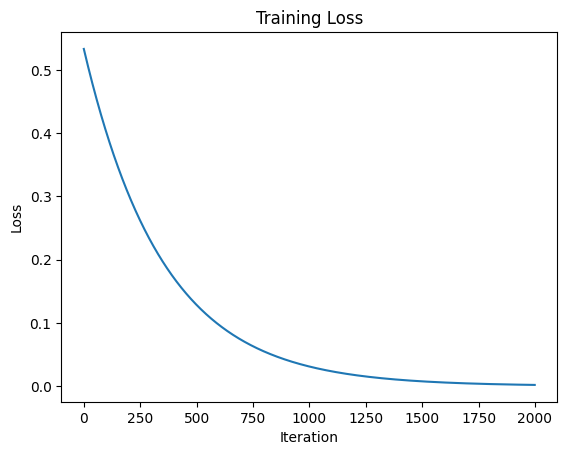

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 2000
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos.flatten()

# Sample noise once with the same shape
# as the real molecules
noise = torch.randn_like(real_mol.pos).flatten()

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(noise)
    V = real_pos - gen_mol
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

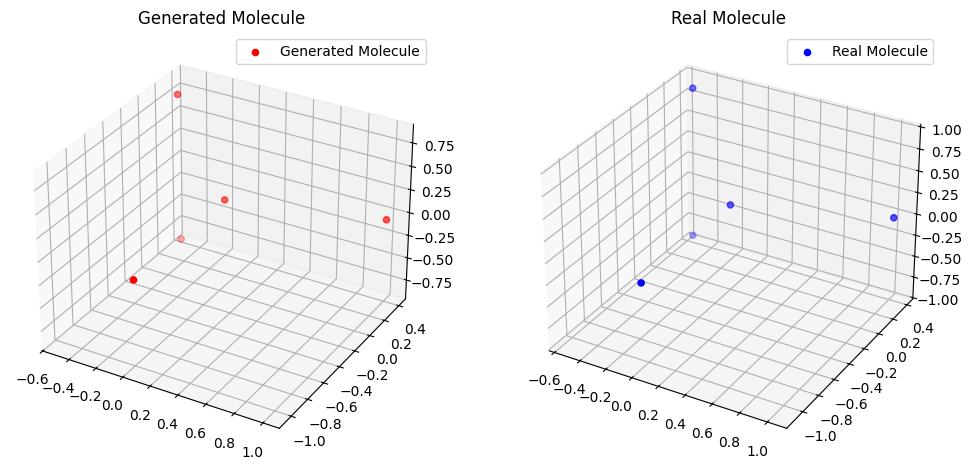

In [ ]:
visualize_both_molecules(gen_mol, real_pos)

# Sample Multiple Noise ONCE

Number of nodes: 5
Center of mass of real molecule positions: tensor([0., 0., 0.])
Std of real molecule positions: tensor([1.0000, 1.0000, 1.0000])
Center of mass of noise: tensor([ 5.1409e-09,  3.9581e-11, -1.7881e-08])
Std of noise: tensor([1.0000, 1.0000, 1.0000])

Iter 499: Loss = 0.28145280480384827
Iter 999: Loss = 0.09717267006635666
Iter 1499: Loss = 0.04417749494314194
Iter 1999: Loss = 0.025161700323224068
Iter 2499: Loss = 0.01648928038775921
Iter 2999: Loss = 0.011644795536994934
Iter 3499: Loss = 0.008565734140574932
Iter 3999: Loss = 0.006465767044574022
Iter 4499: Loss = 0.004976531490683556
Iter 4999: Loss = 0.003893888322636485
Iter 5499: Loss = 0.003092003520578146
Iter 5999: Loss = 0.0024885586462914944
Iter 6499: Loss = 0.002027867129072547
Iter 6999: Loss = 0.0016714290250092745
Iter 7499: Loss = 0.0013921801000833511
Iter 7999: Loss = 0.001170830219052732
Iter 8499: Loss = 0.0009934401605278254
Iter 8999: Loss = 0.0008498221868649125
Iter 9499: Loss = 0.0007324308

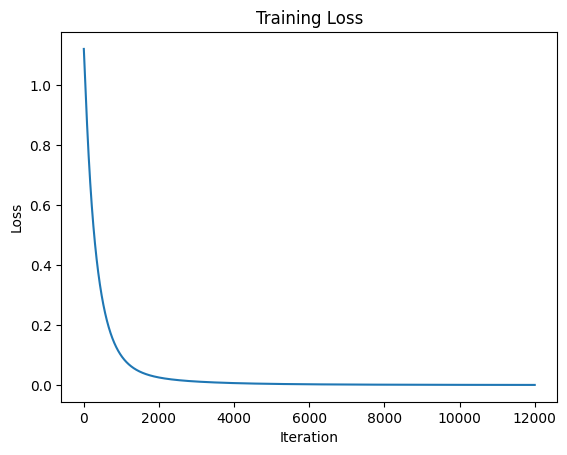

In [ ]:
import torch
import torch.nn.functional as F


NUM_ITERS = 12000
N_GEN_MOLS = 10
LR = 0.005

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")
real_pos = real_pos.flatten()


# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
# We keep this here to be explicit about debugging prints
noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3))
batch_vec = torch.arange(N_GEN_MOLS).repeat_interleave(real_mol.num_nodes)
noise = center_positions_per_mol(noise, batch_vec)
noise = noise / noise.std(dim=0)
print(f"Center of mass of noise: {global_mean_pool(noise, batch_vec).mean(dim=0)}")
print(f"Std of noise: {noise.std(dim=0)}")
print()
noise = noise.view(N_GEN_MOLS, -1)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(noise)
    V = compute_drifting_field(gen_mol, real_pos.unsqueeze(0))
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 500 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

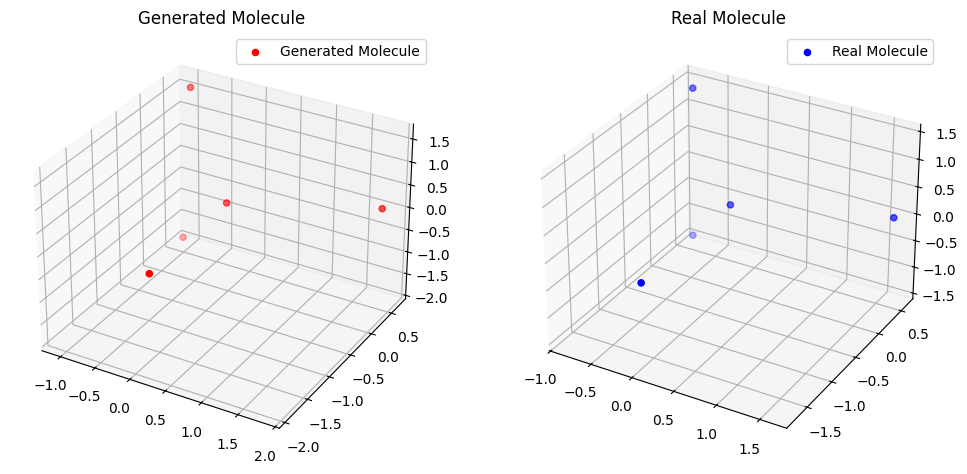

In [ ]:
sorted_mols, _ = get_sorted_mols(gen_mol, real_pos.unsqueeze(0))
visualize_both_molecules(sorted_mols[9].view(-1, 3), real_pos.view(-1, 3))

# Sample DIFFERENT noise every time

Number of nodes: 5
Iter 499: Loss = 1.0157642364501953
Iter 999: Loss = 0.9831550121307373
Iter 1499: Loss = 0.7706218361854553
Iter 1999: Loss = 0.6246938109397888
Iter 2499: Loss = 0.5060461163520813
Iter 2999: Loss = 0.42866250872612
Iter 3499: Loss = 0.3743332028388977
Iter 3999: Loss = 0.36626681685447693
Iter 4499: Loss = 0.2866996228694916
Iter 4999: Loss = 0.2729075849056244
Iter 5499: Loss = 0.2685152590274811
Iter 5999: Loss = 0.1858794093132019
Iter 6499: Loss = 0.17868980765342712
Iter 6999: Loss = 0.19099105894565582
Iter 7499: Loss = 0.13358688354492188
Iter 7999: Loss = 0.11979545652866364
Iter 8499: Loss = 0.12159059196710587
Iter 8999: Loss = 0.08302221447229385
Iter 9499: Loss = 0.07051222771406174
Iter 9999: Loss = 0.07324952632188797
Iter 10499: Loss = 0.05655067414045334
Iter 10999: Loss = 0.036108896136283875
Iter 11499: Loss = 0.0649903193116188
Iter 11999: Loss = 0.04492269083857536
Iter 12499: Loss = 0.04000759869813919
Iter 12999: Loss = 0.024394750595092773
I

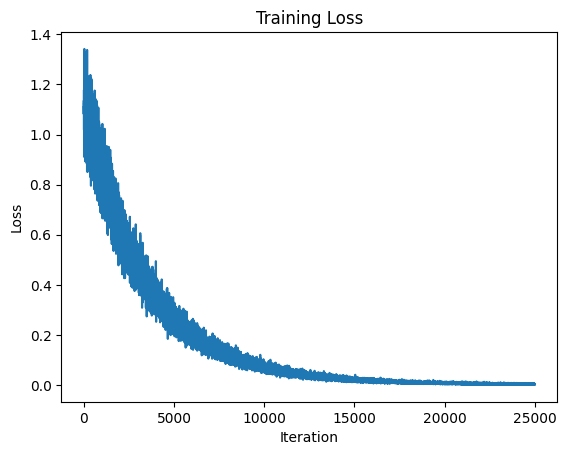

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 25000
N_GEN_MOLS = 10
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.flatten()

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Train model
loss_list, model = train(
    model,
    optimizer,
    NUM_ITERS,
    N_GEN_MOLS,
    num_nodes=real_mol.num_nodes
)

plot_loss(loss_list)

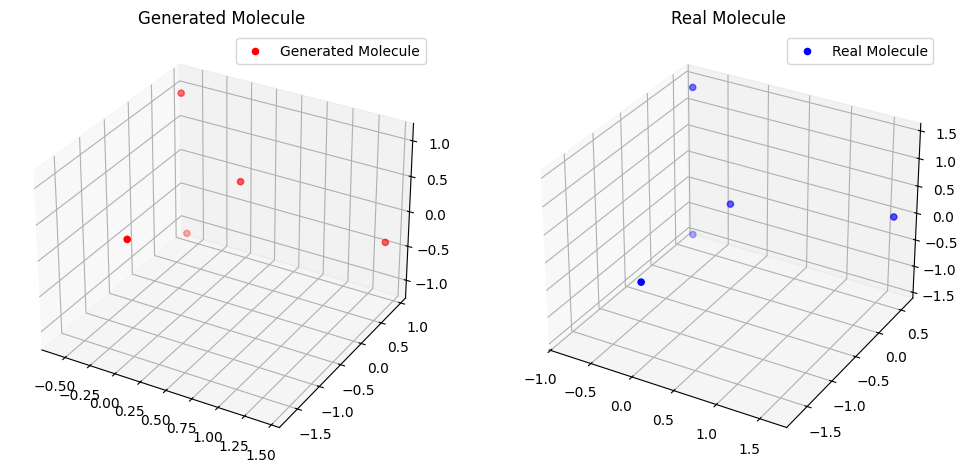

In [ ]:
noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
noise = noise.view(N_GEN_MOLS, -1)
gen_mol = model(noise)

sorted_mols, _ = get_sorted_mols(gen_mol.view(-1, 3), real_pos.view(-1, 3))
visualize_both_molecules(sorted_mols[9], real_pos)

# One Gen Mol and One Real Mol WITH Atom Types

Number of nodes: 5
Real molecule positions shape: torch.Size([5, 3])
Real molecule atom types shape: torch.Size([5, 5])
Combined real molecule shape: torch.Size([40])
Position noise shape: torch.Size([5, 3])
Combined noise shape: torch.Size([40])

Iter 99: Loss = 0.5600471496582031
Iter 199: Loss = 0.4228397011756897
Iter 299: Loss = 0.3192470669746399
Iter 399: Loss = 0.24103383719921112
Iter 499: Loss = 0.18198230862617493
Iter 599: Loss = 0.13739798963069916
Iter 699: Loss = 0.1037365049123764
Iter 799: Loss = 0.07832182198762894
Iter 899: Loss = 0.05913354828953743
Iter 999: Loss = 0.044646255671978
Iter 1099: Loss = 0.03370827063918114
Iter 1199: Loss = 0.025449994951486588
Iter 1299: Loss = 0.019214939326047897
Iter 1399: Loss = 0.014507418498396873
Iter 1499: Loss = 0.010953198187053204
Iter 1599: Loss = 0.008269750513136387
Iter 1699: Loss = 0.006243717856705189
Iter 1799: Loss = 0.004714058246463537
Iter 1899: Loss = 0.0035591486375778913
Iter 1999: Loss = 0.002687184605747461

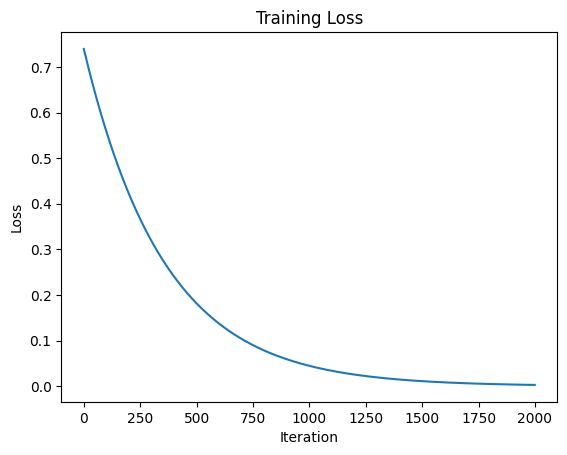

In [72]:
import torch
import torch.nn.functional as F

NUM_ITERS = 2000
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Real molecule positions shape: {real_pos.shape}")

real_types = real_mol.real_atom_types
print(f"Real molecule atom types shape: {real_types.shape}")
real_mol_combined = torch.cat([real_pos, real_types], dim=1)
real_mol_combined = real_mol_combined.flatten()
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
pos_noise = torch.randn((real_mol.num_nodes, 3))
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
print(f"Position noise shape: {pos_noise.shape}")

# We sample random noise as embedding for atom types
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES))
combined_noise = torch.cat([pos_noise, type_noise], dim=1).flatten()
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(combined_noise)
    V = real_mol_combined - gen_mol
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Generated atom types (rounded): 
 tensor([[-0., 1., 0., 0., -0.],
        [1., -0., -0., -0., 0.],
        [1., -0., -0., -0., 0.],
        [1., -0., 0., 0., 0.],
        [1., -0., 0., 0., -0.]], grad_fn=<RoundBackward0>)
torch.Size([5])


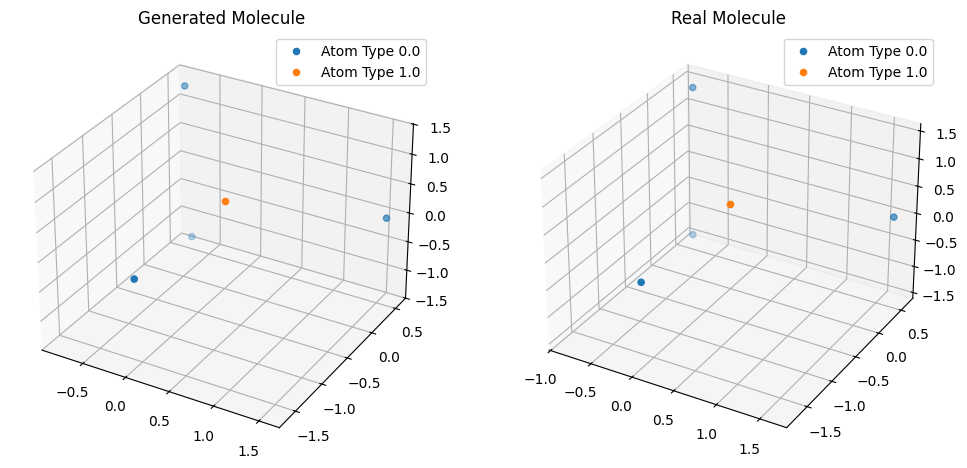

In [74]:
gen_pos, gen_types = gen_mol.view(
    real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Generated atom types (rounded): \n {gen_types.round()}")

gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

print(real_types_argmax.shape)

visualize_both_molecules_with_atom_types(
    gen_pos, gen_types_argmax, real_pos, real_types_argmax
)

# Atom Types + Pos | Multiple Noise and One Mol

Overfitting is possible with enough training time. Repulsion should not be a problem here.

Number of nodes: 5
Combined real molecule shape: torch.Size([40])
Position noise shape: torch.Size([50, 3])
Type noise shape: torch.Size([50, 5])
Combined noise shape: torch.Size([10, 40])

Iter 99: Loss = 0.5948534607887268
Iter 199: Loss = 0.5565013289451599
Iter 299: Loss = 0.5205962657928467
Iter 399: Loss = 0.48696067929267883
Iter 499: Loss = 0.4554285407066345
Iter 599: Loss = 0.42584601044654846
Iter 699: Loss = 0.3980737030506134
Iter 799: Loss = 0.37198635935783386
Iter 899: Loss = 0.3474729061126709
Iter 999: Loss = 0.3244354724884033
Iter 1099: Loss = 0.3027886152267456
Iter 1199: Loss = 0.2824574410915375
Iter 1299: Loss = 0.26337602734565735
Iter 1399: Loss = 0.24548529088497162
Iter 1499: Loss = 0.228731170296669
Iter 1599: Loss = 0.2130628526210785
Iter 1699: Loss = 0.19843131303787231
Iter 1799: Loss = 0.18478824198246002
Iter 1899: Loss = 0.17208534479141235
Iter 1999: Loss = 0.16027390956878662
Iter 2099: Loss = 0.14930495619773865
Iter 2199: Loss = 0.139129251241683

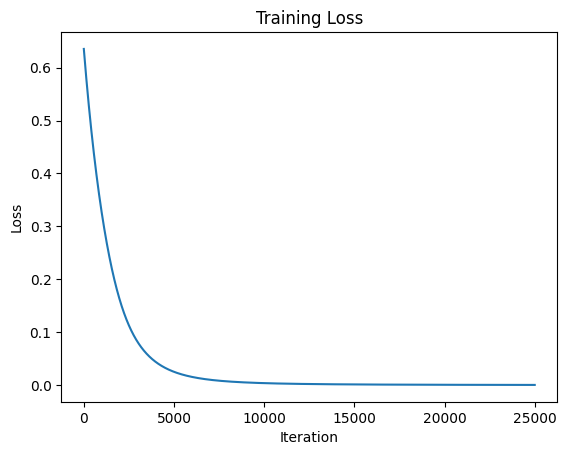

In [78]:
import torch
import torch.nn.functional as F

NUM_ITERS = 25000
N_GEN_MOLS = 10
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.view(1, -1)

real_types = real_mol.real_atom_types.view(1, -1)
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
type_noise = sample_type_noise(N_GEN_MOLS, real_mol.num_nodes, NUM_ATOM_TYPES)
print(f"Position noise shape: {pos_noise.shape}")
print(f"Type noise shape: {type_noise.shape}")
combined_noise = torch.cat([pos_noise, type_noise], dim=1)
combined_noise = combined_noise.view(N_GEN_MOLS, -1)
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * real_mol.num_nodes, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 1.0


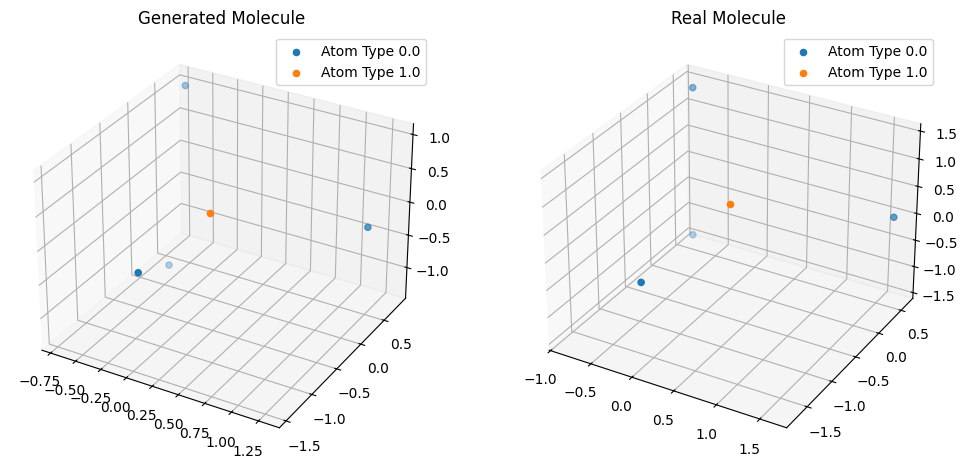

In [ ]:
gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), real_pos
)

SELECTED_IDX = 9

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, real_pos.view(-1, 3), real_types_argmax
)

# Pos + Types | Different Noise Every Time

Number of nodes: 5
Combined real molecule shape: torch.Size([40])
Iter 99: Loss = 0.7120481729507446
Iter 199: Loss = 0.6479562520980835
Iter 299: Loss = 0.617200493812561
Iter 399: Loss = 0.6756860613822937
Iter 499: Loss = 0.6873117685317993
Iter 599: Loss = 0.686601996421814
Iter 699: Loss = 0.8294133543968201
Iter 799: Loss = 0.7824108004570007
Iter 899: Loss = 0.6966568231582642
Iter 999: Loss = 0.6402565240859985
Iter 1099: Loss = 0.7394413948059082
Iter 1199: Loss = 0.625499963760376
Iter 1299: Loss = 0.6306924819946289
Iter 1399: Loss = 0.5787439942359924
Iter 1499: Loss = 0.6077677607536316
Iter 1599: Loss = 0.6584140062332153
Iter 1699: Loss = 0.6161024570465088
Iter 1799: Loss = 0.632632851600647
Iter 1899: Loss = 0.6448901295661926
Iter 1999: Loss = 0.6501623392105103
Iter 2099: Loss = 0.5643665194511414
Iter 2199: Loss = 0.5894235968589783
Iter 2299: Loss = 0.5763906836509705
Iter 2399: Loss = 0.6329619884490967
Iter 2499: Loss = 0.5467102527618408
Iter 2599: Loss = 0.6014

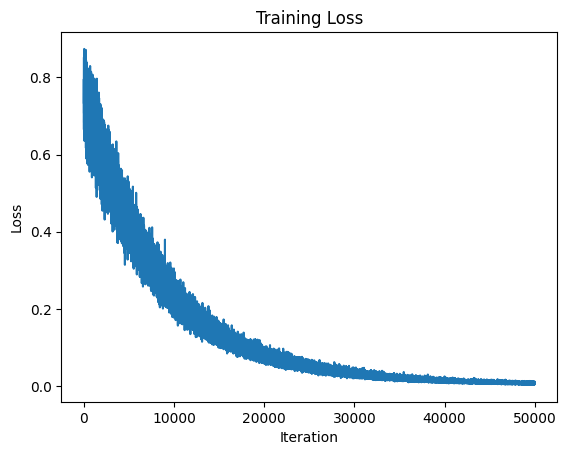

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 50000
N_GEN_MOLS = 10
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.view(1, -1)
real_types = real_mol.real_atom_types.view(1, -1)

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise as before
    pos_noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
    type_noise = sample_type_noise(N_GEN_MOLS, real_mol.num_nodes, NUM_ATOM_TYPES)
    combined_noise = torch.cat([pos_noise, type_noise], dim=1)
    combined_noise = combined_noise.view(N_GEN_MOLS, -1)


    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * real_mol.num_nodes, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 1.0


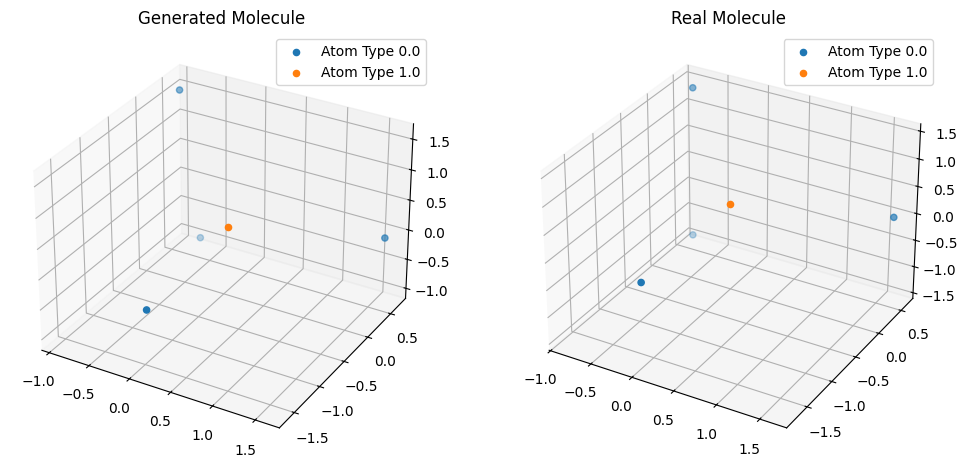

In [ ]:
gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), real_pos
)

SELECTED_IDX = 0

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, real_pos.view(-1, 3), real_types_argmax
)

# Multiple Real Molecules with Same Number of atoms

Center of mass of real molecule positions: tensor([5.9605e-09, 2.3842e-08, 2.3842e-08])
Std of real molecule positions: tensor([1., 1., 1.])

Iter 99: Loss = 0.5311100482940674
Iter 199: Loss = 0.7114846110343933
Iter 299: Loss = 0.5479442477226257
Iter 399: Loss = 0.5650913119316101
Iter 499: Loss = 0.4880775809288025
Iter 599: Loss = 0.6004557013511658
Iter 699: Loss = 0.5779122710227966
Iter 799: Loss = 0.5189532041549683
Iter 899: Loss = 0.5024405717849731
Iter 999: Loss = 0.522939920425415
Iter 1099: Loss = 0.568645179271698
Iter 1199: Loss = 0.5696749091148376
Iter 1299: Loss = 0.494282990694046
Iter 1399: Loss = 0.5523578524589539
Iter 1499: Loss = 0.5027629733085632
Iter 1599: Loss = 0.5196371674537659
Iter 1699: Loss = 0.48137524724006653
Iter 1799: Loss = 0.44199326634407043
Iter 1899: Loss = 0.5195161700248718
Iter 1999: Loss = 0.499693363904953
Iter 2099: Loss = 0.45572713017463684
Iter 2199: Loss = 0.508460521697998
Iter 2299: Loss = 0.45072007179260254
Iter 2399: Loss = 0

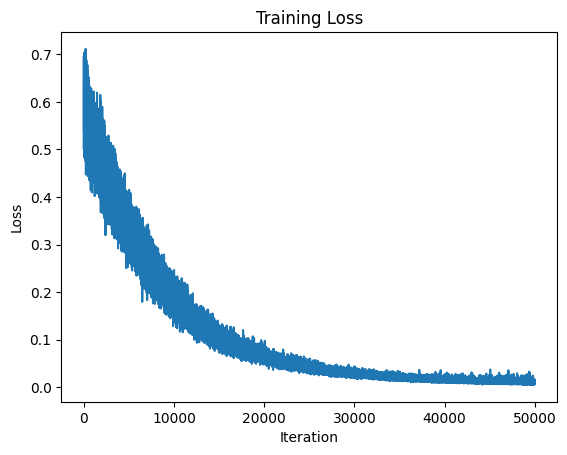

In [131]:
import torch
import torch.nn.functional as F

NUM_ITERS = 50000
N_GEN_MOLS = 10
N_REAL_MOLS = 2
NUM_ATOM_TYPES = 5
NUM_ATOMS = 5
LR = 0.001

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= N_REAL_MOLS:
        break
filtered_dataset = dataset.index_select(keep)

batch_vec = torch.arange(N_REAL_MOLS).repeat_interleave(NUM_ATOMS)
real_pos = center_positions_per_mol(
    filtered_dataset.pos, batch_vec
)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Center of mass of real molecule positions: {global_mean_pool(real_pos, batch_vec).mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")
print()

real_pos = real_pos.view(N_REAL_MOLS, -1)
real_types = filtered_dataset.real_atom_types.view(N_REAL_MOLS, -1)

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=NUM_ATOMS, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise as before
    pos_noise = sample_pos_noise(N_GEN_MOLS, NUM_ATOMS)
    type_noise = sample_type_noise(N_GEN_MOLS, NUM_ATOMS, NUM_ATOM_TYPES)
    combined_noise = torch.cat([pos_noise, type_noise], dim=1)
    combined_noise = combined_noise.view(N_GEN_MOLS, -1)


    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * NUM_ATOMS, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * NUM_ATOMS, 3)
    V_types = V_types.view(N_GEN_MOLS * NUM_ATOMS, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


In [133]:
real_pos.shape, real_types.shape

(torch.Size([2, 15]), torch.Size([2, 25]))

Mean of rounded atom types: 0.9599999785423279


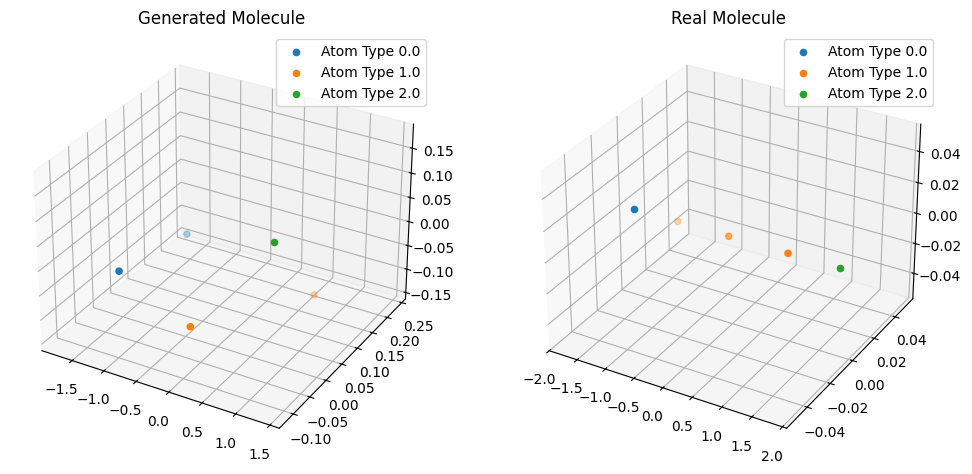

In [137]:
REAL_MOL_IDX = 1

selected_real_pos = real_pos[REAL_MOL_IDX].view(1, -1)
selected_real_types = real_types[REAL_MOL_IDX].view(1, -1)

gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * NUM_ATOMS, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), selected_real_pos
)

SELECTED_IDX = 0

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = selected_real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, selected_real_pos.view(-1, 3), real_types_argmax
)